In [2]:
# Run this once to install if not already installed
# !pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("✅ All libraries imported successfully!")
print(f"Pandas version  : {pd.__version__}")
print(f"NumPy version   : {np.__version__}")

✅ All libraries imported successfully!
Pandas version  : 2.2.2
NumPy version   : 1.26.4


In [3]:
# Load all 3 CSV files from the data folder
players      = pd.read_csv("data/players.csv")
items        = pd.read_csv("data/items.csv")
interactions = pd.read_csv("data/interactions.csv")

# Preview each file
print("=" * 50)
print("👥 PLAYERS — first 3 rows")
print("=" * 50)
print(players.head(3))

print("\n" + "=" * 50)
print("🎮 ITEMS — first 3 rows")
print("=" * 50)
print(items.head(3))

print("\n" + "=" * 50)
print("⭐ INTERACTIONS — first 3 rows")
print("=" * 50)
print(interactions.head(3))

👥 PLAYERS — first 3 rows
   player_id player_name  level  play_style  matches_played
0          1    Player_1     39  aggressive             233
1          2    Player_2     29    explorer             234
2          3    Player_3     15     support             394

🎮 ITEMS — first 3 rows
   item_id         item_name category     type     rarity  damage  range  \
0        1  Assault Rifle M4   Weapon    Rifle     Common      45     70   
1        2        Sniper AWM   Weapon   Sniper  Legendary     100    100   
2        3      Shotgun S12K   Weapon  Shotgun   Uncommon      80     25   

   fire_rate  price  xp_reward difficulty  
0         80    500        NaN        NaN  
1         20   2000        NaN        NaN  
2         40    700        NaN        NaN  

⭐ INTERACTIONS — first 3 rows
   player_id player_name  item_id         item_name category  rating  \
0          1    Player_1        2        Sniper AWM   Weapon       3   
1          1    Player_1       48  Land at Hot Zone  Mi

In [4]:
print("=" * 50)
print("📊 DATASET SIZES")
print("=" * 50)
print(f"Players      : {players.shape[0]} rows, {players.shape[1]} columns")
print(f"Items        : {items.shape[0]} rows, {items.shape[1]} columns")
print(f"Interactions : {interactions.shape[0]} rows, {interactions.shape[1]} columns")

print("\n Column names:")
print(f"Players      : {list(players.columns)}")
print(f"Items        : {list(items.columns)}")
print(f"Interactions : {list(interactions.columns)}")

📊 DATASET SIZES
Players      : 100 rows, 5 columns
Items        : 60 rows, 11 columns
Interactions : 688 rows, 7 columns

 Column names:
Players      : ['player_id', 'player_name', 'level', 'play_style', 'matches_played']
Items        : ['item_id', 'item_name', 'category', 'type', 'rarity', 'damage', 'range', 'fire_rate', 'price', 'xp_reward', 'difficulty']
Interactions : ['player_id', 'player_name', 'item_id', 'item_name', 'category', 'rating', 'play_style']


In [5]:
print("=" * 50)
print("🔍 MISSING VALUES CHECK")
print("=" * 50)

print("\n👥 Players missing values:")
print(players.isnull().sum())

print("\n🎮 Items missing values:")
print(items.isnull().sum())

print("\n⭐ Interactions missing values:")
print(interactions.isnull().sum())

# Total missing
total_missing = (players.isnull().sum().sum() +
                 items.isnull().sum().sum() +
                 interactions.isnull().sum().sum())

if total_missing == 0:
    print("\n✅ No missing values found! Data is clean.")
else:
    print(f"\n⚠️ Total missing values found: {total_missing}")

🔍 MISSING VALUES CHECK

👥 Players missing values:
player_id         0
player_name       0
level             0
play_style        0
matches_played    0
dtype: int64

🎮 Items missing values:
item_id        0
item_name      0
category       0
type           0
rarity         0
damage         0
range          0
fire_rate      0
price          0
xp_reward     40
difficulty    40
dtype: int64

⭐ Interactions missing values:
player_id      0
player_name    0
item_id        0
item_name      0
category       0
rating         0
play_style     0
dtype: int64

⚠️ Total missing values found: 80


In [6]:
print("=" * 50)
print("🔁 DUPLICATE ROWS CHECK")
print("=" * 50)

p_dups = players.duplicated().sum()
i_dups = items.duplicated().sum()
r_dups = interactions.duplicated().sum()

print(f"Players duplicates      : {p_dups}")
print(f"Items duplicates        : {i_dups}")
print(f"Interactions duplicates : {r_dups}")

# Remove duplicates if any
players      = players.drop_duplicates()
items        = items.drop_duplicates()
interactions = interactions.drop_duplicates()

# Check for duplicate player+item combinations
combo_dups = interactions.duplicated(subset=["player_id", "item_id"]).sum()
print(f"\nDuplicate player+item combos: {combo_dups}")

if combo_dups > 0:
    # Keep only the last rating if a player rated same item twice
    interactions = interactions.drop_duplicates(subset=["player_id", "item_id"], keep="last")
    print("✅ Duplicate combos removed — kept latest rating")
else:
    print("✅ No duplicate player+item combos found!")

🔁 DUPLICATE ROWS CHECK
Players duplicates      : 0
Items duplicates        : 0
Interactions duplicates : 0

Duplicate player+item combos: 0
✅ No duplicate player+item combos found!


In [7]:
print("=" * 50)
print("🔢 DATA TYPES CHECK")
print("=" * 50)

print("\n👥 Players:")
print(players.dtypes)

print("\n🎮 Items:")
print(items.dtypes)

print("\n⭐ Interactions:")
print(interactions.dtypes)

# Make sure rating is integer
interactions["rating"] = interactions["rating"].astype(int)
players["level"]       = players["level"].astype(int)
items["price"]         = items["price"].astype(int)

print("\n✅ Data types confirmed and fixed!")

🔢 DATA TYPES CHECK

👥 Players:
player_id          int64
player_name       object
level              int64
play_style        object
matches_played     int64
dtype: object

🎮 Items:
item_id         int64
item_name      object
category       object
type           object
rarity         object
damage          int64
range           int64
fire_rate       int64
price           int64
xp_reward     float64
difficulty     object
dtype: object

⭐ Interactions:
player_id       int64
player_name    object
item_id         int64
item_name      object
category       object
rating          int64
play_style     object
dtype: object

✅ Data types confirmed and fixed!


In [5]:
print("=" * 50)
print("📈 BASIC STATISTICS")
print("=" * 50)

print(f"\nTotal unique players     : {interactions['player_id'].nunique()}")
print(f"Total unique items       : {interactions['item_id'].nunique()}")
print(f"Total interactions       : {len(interactions)}")
print(f"Average rating           : {interactions['rating'].mean():.2f}")
print(f"Min rating               : {interactions['rating'].min()}")
print(f"Max rating               : {interactions['rating'].max()}")

print(f"\n📦 Item categories:")
print(interactions["category"].value_counts())

print(f"\n🎮 Player play styles:")
print(players["play_style"].value_counts())

print(f"\n⭐ Rating distribution:")
print(interactions["rating"].value_counts().sort_index())

📈 BASIC STATISTICS

Total unique players     : 100
Total unique items       : 60
Total interactions       : 688
Average rating           : 3.68
Min rating               : 2
Max rating               : 5

📦 Item categories:
category
Weapon     235
Mission    229
Skin       224
Name: count, dtype: int64

🎮 Player play styles:
play_style
aggressive    26
support       23
explorer      21
collector     16
sniper        14
Name: count, dtype: int64

⭐ Rating distribution:
rating
2    150
3    151
4    159
5    228
Name: count, dtype: int64


In [6]:
print("=" * 50)
print("🏗️ BUILDING USER-ITEM MATRIX")
print("=" * 50)

# Pivot table: rows = players, columns = items, values = ratings
# Missing values (items not rated) filled with 0
user_item_matrix = interactions.pivot_table(
    index   = "player_id",
    columns = "item_id",
    values  = "rating",
    fill_value = 0
)

print(f"Matrix shape: {user_item_matrix.shape}")
print(f"  → {user_item_matrix.shape[0]} players (rows)")
print(f"  → {user_item_matrix.shape[1]} items   (columns)")

# Calculate sparsity
total_cells    = user_item_matrix.shape[0] * user_item_matrix.shape[1]
filled_cells   = (user_item_matrix != 0).sum().sum()
empty_cells    = total_cells - filled_cells
sparsity       = (empty_cells / total_cells) * 100

print(f"\n📊 Matrix statistics:")
print(f"  Total cells    : {total_cells}")
print(f"  Rated cells    : {filled_cells}")
print(f"  Empty cells    : {empty_cells}")
print(f"  Sparsity       : {sparsity:.1f}%")

print("\n📋 Matrix preview (first 5 players, first 8 items):")
print(user_item_matrix.iloc[:5, :8])

🏗️ BUILDING USER-ITEM MATRIX
Matrix shape: (100, 60)
  → 100 players (rows)
  → 60 items   (columns)

📊 Matrix statistics:
  Total cells    : 6000
  Rated cells    : 688
  Empty cells    : 5312
  Sparsity       : 88.5%

📋 Matrix preview (first 5 players, first 8 items):
item_id      1    2    3    4    5    6    7    8
player_id                                        
1          0.0  3.0  0.0  0.0  0.0  0.0  0.0  0.0
2          0.0  0.0  0.0  0.0  0.0  2.0  0.0  0.0
3          3.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
4          0.0  0.0  4.0  0.0  0.0  0.0  0.0  0.0
5          0.0  0.0  3.0  0.0  0.0  0.0  0.0  0.0


In [7]:
# Create outputs folder if it doesn't exist
os.makedirs("outputs", exist_ok=True)

# Save user-item matrix for Members 2 and 3 to use
user_item_matrix.to_csv("data/user_item_matrix.csv")

print("✅ User-item matrix saved to: data/user_item_matrix.csv")
print(f"   Shape: {user_item_matrix.shape}")
print(f"   File ready for Member 2 (Collaborative Filtering)")
print(f"   File ready for Member 3 (Content-Based Filtering)")

✅ User-item matrix saved to: data/user_item_matrix.csv
   Shape: (100, 60)
   File ready for Member 2 (Collaborative Filtering)
   File ready for Member 3 (Content-Based Filtering)


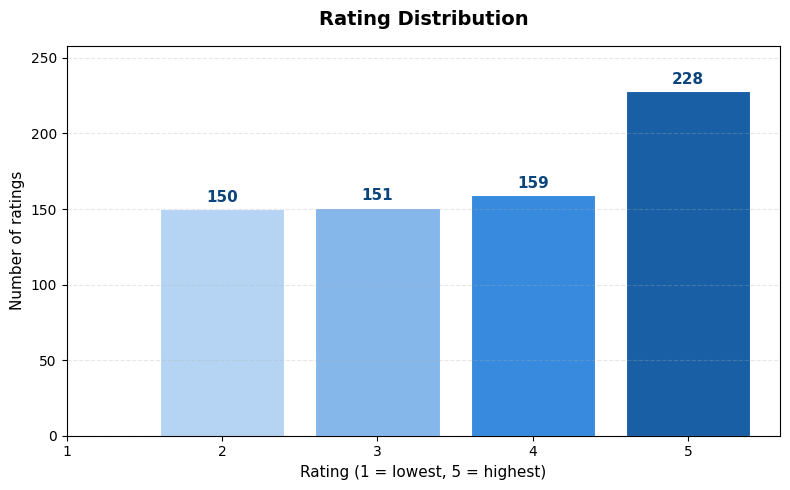

✅ Chart 1 saved: outputs/chart1_rating_distribution.png


In [8]:
plt.figure(figsize=(8, 5))

# Count each rating value
rating_counts = interactions["rating"].value_counts().sort_index()

# Color each bar differently
colors = ["#B5D4F4", "#85B7EB", "#378ADD", "#185FA5", "#0C447C"]
bars = plt.bar(rating_counts.index, rating_counts.values,
               color=colors, edgecolor="white", linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 3,
             str(val),
             ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="#0C447C")

plt.title("Rating Distribution", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Rating (1 = lowest, 5 = highest)", fontsize=11)
plt.ylabel("Number of ratings", fontsize=11)
plt.xticks([1, 2, 3, 4, 5])
plt.ylim(0, rating_counts.max() + 30)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("outputs/chart1_rating_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 1 saved: outputs/chart1_rating_distribution.png")

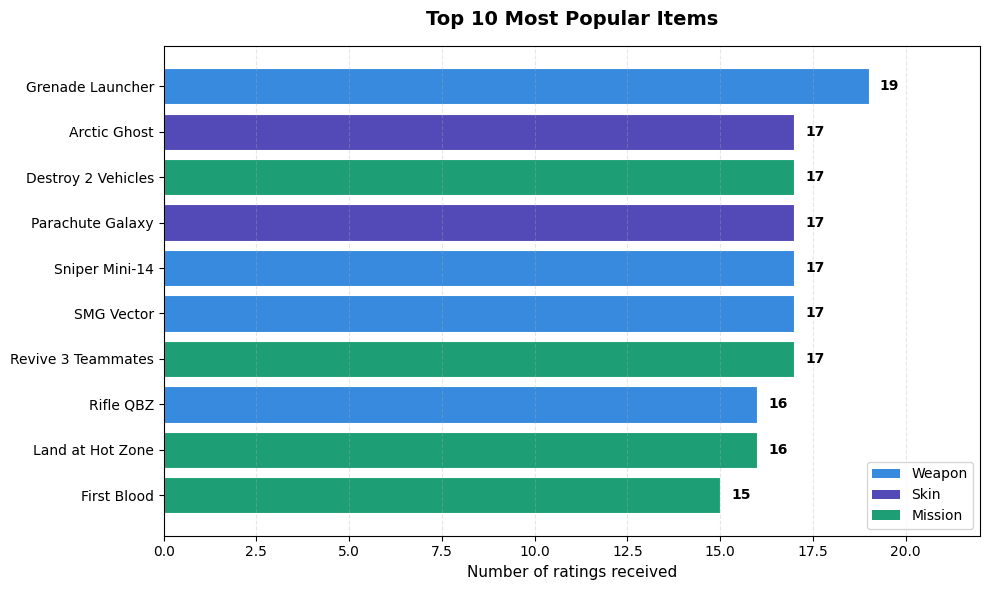

✅ Chart 2 saved: outputs/chart2_popular_items.png


In [9]:
plt.figure(figsize=(10, 6))

# Count how many times each item was rated
item_popularity = interactions.groupby("item_name")["rating"].count().sort_values(ascending=False).head(10)

# Color by category
top_item_names = item_popularity.index.tolist()
category_colors = {
    "Weapon":  "#378ADD",
    "Skin":    "#534AB7",
    "Mission": "#1D9E75"
}
bar_colors = []
for name in top_item_names:
    cat = interactions[interactions["item_name"] == name]["category"].values[0]
    bar_colors.append(category_colors.get(cat, "#888780"))

bars = plt.barh(top_item_names[::-1], item_popularity.values[::-1],
                color=bar_colors[::-1], edgecolor="white", linewidth=0.8)

# Add value labels
for bar, val in zip(bars, item_popularity.values[::-1]):
    plt.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
             str(val), va="center", fontsize=10, fontweight="bold")

# Custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#378ADD", label="Weapon"),
    Patch(facecolor="#534AB7", label="Skin"),
    Patch(facecolor="#1D9E75", label="Mission"),
]
plt.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.title("Top 10 Most Popular Items", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Number of ratings received", fontsize=11)
plt.xlim(0, item_popularity.max() + 3)
plt.grid(axis="x", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("outputs/chart2_popular_items.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 2 saved: outputs/chart2_popular_items.png")

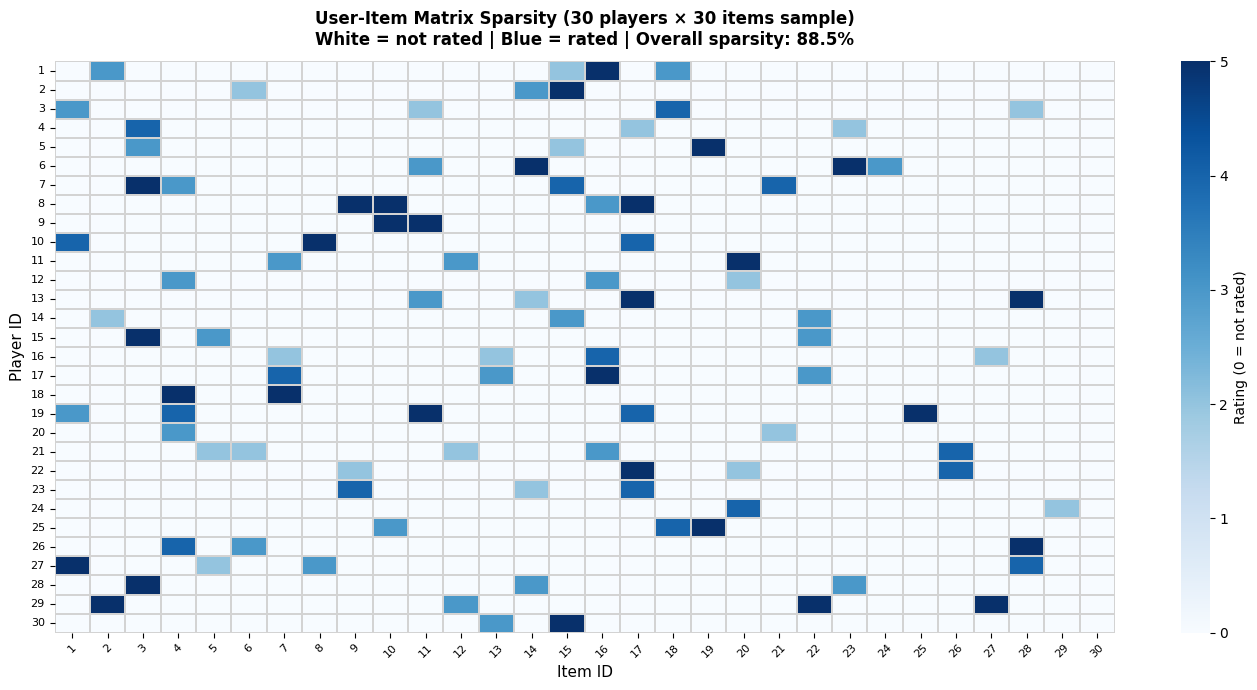

✅ Chart 3 saved: outputs/chart3_sparsity_heatmap.png


In [10]:
plt.figure(figsize=(14, 7))

# Use a sample of 30 players and 30 items for readability
sample_matrix = user_item_matrix.iloc[:30, :30]

# Create heatmap — blue = rated, white = not rated
sns.heatmap(
    sample_matrix,
    cmap       = "Blues",
    linewidths = 0.3,
    linecolor  = "lightgray",
    cbar_kws   = {"label": "Rating (0 = not rated)"},
    xticklabels = True,
    yticklabels = True
)

plt.title(
    f"User-Item Matrix Sparsity (30 players × 30 items sample)\n"
    f"White = not rated | Blue = rated | Overall sparsity: {sparsity:.1f}%",
    fontsize=12, fontweight="bold", pad=12
)
plt.xlabel("Item ID", fontsize=11)
plt.ylabel("Player ID", fontsize=11)
plt.xticks(fontsize=8, rotation=45)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.savefig("outputs/chart3_sparsity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart 3 saved: outputs/chart3_sparsity_heatmap.png")

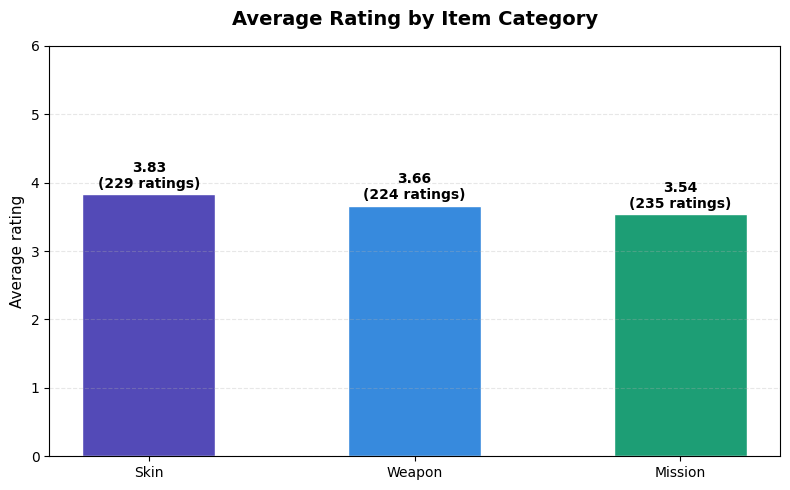

✅ Bonus chart saved: outputs/chart4_avg_rating_category.png


In [11]:
plt.figure(figsize=(8, 5))

# Average rating per category
avg_by_category = interactions.groupby("category")["rating"].mean().sort_values(ascending=False)
count_by_category = interactions.groupby("category")["rating"].count()

colors = {"Weapon": "#378ADD", "Skin": "#534AB7", "Mission": "#1D9E75"}
bar_colors = [colors.get(c, "#888780") for c in avg_by_category.index]

bars = plt.bar(avg_by_category.index, avg_by_category.values,
               color=bar_colors, edgecolor="white", width=0.5)

for bar, val, count in zip(bars, avg_by_category.values, count_by_category.values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.05,
             f"{val:.2f}\n({count} ratings)",
             ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.title("Average Rating by Item Category", fontsize=14, fontweight="bold", pad=15)
plt.ylabel("Average rating", fontsize=11)
plt.ylim(0, 6)
plt.grid(axis="y", alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("outputs/chart4_avg_rating_category.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Bonus chart saved: outputs/chart4_avg_rating_category.png")

In [12]:
print("=" * 55)
print("✅  MEMBER 1 — PREPROCESSING COMPLETE")
print("=" * 55)

print("""
📁 Files created:
   data/user_item_matrix.csv         ← for Members 2 & 3
   outputs/chart1_rating_distribution.png
   outputs/chart2_popular_items.png
   outputs/chart3_sparsity_heatmap.png
   outputs/chart4_avg_rating_category.png
""")

print("📊 Final dataset summary:")
print(f"   Players        : {players['player_id'].nunique()}")
print(f"   Items          : {items['item_id'].nunique()}")
print(f"   Interactions   : {len(interactions)}")
print(f"   Avg rating     : {interactions['rating'].mean():.2f}")
print(f"   Matrix shape   : {user_item_matrix.shape}")
print(f"   Sparsity       : {sparsity:.1f}%")

print("""
📝 Report section to write:
   - Dataset description (players, items, interactions)
   - How data was generated
   - Key statistics (sparsity, avg rating)
   - Attach the 3 charts above
""")

print("🏁 Hand over to Member 2 and Member 3:")
print("   Give them: data/ folder with all CSV files")
print("   They need: interactions.csv, items.csv, user_item_matrix.csv")

✅  MEMBER 1 — PREPROCESSING COMPLETE

📁 Files created:
   data/user_item_matrix.csv         ← for Members 2 & 3
   outputs/chart1_rating_distribution.png
   outputs/chart2_popular_items.png
   outputs/chart3_sparsity_heatmap.png
   outputs/chart4_avg_rating_category.png

📊 Final dataset summary:
   Players        : 100
   Items          : 60
   Interactions   : 688
   Avg rating     : 3.68
   Matrix shape   : (100, 60)
   Sparsity       : 88.5%

📝 Report section to write:
   - Dataset description (players, items, interactions)
   - How data was generated
   - Key statistics (sparsity, avg rating)
   - Attach the 3 charts above

🏁 Hand over to Member 2 and Member 3:
   Give them: data/ folder with all CSV files
   They need: interactions.csv, items.csv, user_item_matrix.csv
